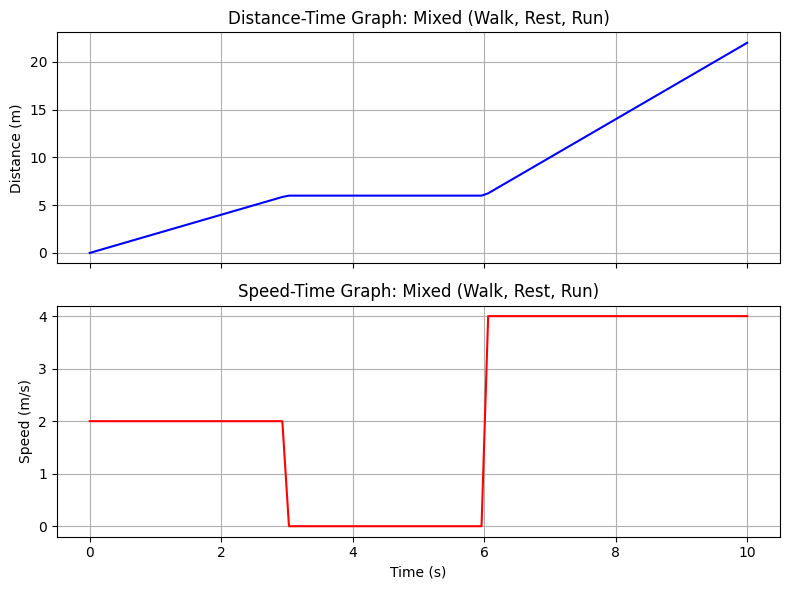

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, Dropdown

# Define motion types
def generate_motion(motion_type):
    time = np.linspace(0, 10, 100)

    if motion_type == "Uniform Motion":
        distance = 2 * time
        speed = np.full_like(time, 2)

    elif motion_type == "Acceleration":
        distance = 0.5 * 1 * time**2
        speed = time

    elif motion_type == "Deceleration":
        distance = -0.5 * time**2 + 10 * time
        speed = -time + 10

    elif motion_type == "Rest":
        distance = np.full_like(time, 5)
        speed = np.zeros_like(time)

    elif motion_type == "Mixed (Walk, Rest, Run)":
        distance = np.piecewise(time,
                                [time <= 3, (time > 3) & (time <= 6), time > 6],
                                [lambda t: 2*t, lambda t: 6, lambda t: 6 + 4*(t-6)])
        speed = np.piecewise(time,
                             [time <= 3, (time > 3) & (time <= 6), time > 6],
                             [2, 0, 4])

    return time, distance, speed

# Plotting function
def plot_motion(motion_type):
    time, distance, speed = generate_motion(motion_type)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    ax1.plot(time, distance, 'b', label='Distance-Time')
    ax1.set_ylabel("Distance (m)")
    ax1.set_title(f"Distance-Time Graph: {motion_type}")
    ax1.grid(True)

    ax2.plot(time, speed, 'r', label='Speed-Time')
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Speed (m/s)")
    ax2.set_title(f"Speed-Time Graph: {motion_type}")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Interactive dropdown
interact(plot_motion,
         motion_type=Dropdown(
             options=["Uniform Motion", "Acceleration", "Deceleration", "Rest", "Mixed (Walk, Rest, Run)"],
             value="Uniform Motion",
             description="Motion Type:"
         ))

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

# Movement functions
def uniform_motion():
    time = np.linspace(0, 10, 100)
    distance = 3 * time  # constant speed
    speed = np.gradient(distance, time)
    return time, distance, speed

def stationary():
    time = np.linspace(0, 10, 100)
    distance = np.zeros_like(time)
    speed = np.gradient(distance, time)
    return time, distance, speed

def accelerated_motion():
    time = np.linspace(0, 10, 100)
    distance = 0.5 * 2 * time**2  # a = 2
    speed = np.gradient(distance, time)
    return time, distance, speed

def decelerated_motion():
    time = np.linspace(0, 10, 100)
    distance = -0.5 * 2 * time**2 + 20 * time  # slowing down
    speed = np.gradient(distance, time)
    return time, distance, speed

def mixed_journey():
    time = np.linspace(0, 30, 300)
    distance = np.piecewise(
        time,
        [time < 10, (time >= 10) & (time < 15), (time >= 15) & (time < 20), time >= 20],
        [lambda t: 2 * t,
         lambda t: 20,
         lambda t: 2 * (t - 15) + 20,
         lambda t: -1 * (t - 20) + 30]
    )
    speed = np.gradient(distance, time)
    return time, distance, speed

# Plot function
def plot_graph(motion_type):
    motion_map = {
        "Uniform Motion": uniform_motion,
        "Stationary": stationary,
        "Accelerated Motion": accelerated_motion,
        "Decelerated Motion": decelerated_motion,
        "Mixed Journey": mixed_journey,
    }

    time, distance, speed = motion_map[motion_type]()

    plt.figure(figsize=(12, 5))

    # Distance-Time Graph
    plt.subplot(1, 2, 1)
    plt.plot(time, distance, label='Distance', color='blue')
    plt.title("Distance-Time Graph")
    plt.xlabel("Time")
    plt.ylabel("Distance")
    plt.grid(True)

    # Speed-Time Graph
    plt.subplot(1, 2, 2)
    plt.plot(time, speed, label='Speed', color='green')
    plt.title("Speed-Time Graph")
    plt.xlabel("Time")
    plt.ylabel("Speed")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Interactive widget
interact(
    plot_graph,
    motion_type=Dropdown(
        options=["Uniform Motion", "Stationary", "Accelerated Motion", "Decelerated Motion", "Mixed Journey"],
        description="Select Movement:"
    )
)


interactive(children=(Dropdown(description='Select Movement:', options=('Uniform Motion', 'Stationary', 'Accel…

<function __main__.plot_graph(motion_type)>